# Practicum Project: Early Gameplay Risk Scoring

**Goal:** Use early gameplay behavior (first 20 actions) to estimate which sessions are more likely to be incorrect.

This Notebook Includes:

- Loading and preparing gameplay and label data

- Engineering overall and early-session behavioral features

- Training and comparing Logistic Regression and Random Forest models

- Creating a risk scoring and stratification framework

- Simulating targeted intervention scenarios

- Evaluating performance by level group

- Optimizing decision thresholds for practical deployment

## Executive Summary

This project develops an early-session risk scoring framework using gameplay telemetry data to identify sessions likely to result in incorrect outcomes.

Behavioral features were engineered from both full-session activity and the first 20 actions of each session. Two models were evaluated: Logistic Regression and Random Forest.

To prevent data leakage, a group-based train-test split was applied at the session level.

The Random Forest model achieved a ROC AUC of approximately 0.64, outperforming Logistic Regression (≈0.61).

Risk stratification shows that the highest-risk 20% of sessions contain approximately 44% of all incorrect outcomes.
Threshold optimization further demonstrates that flagging 38% of sessions can capture roughly 55% of incorrect cases, indicating meaningful intervention potential.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve

DATA_DIR = os.path.expanduser("~/Downloads/predict-student-performance-from-game-play")

assert os.path.exists(DATA_DIR), f"Folder not found: {DATA_DIR}"
os.chdir(DATA_DIR)
print("Working directory:", os.getcwd())

Working directory: /Users/malikibrahimalikhan/Downloads/predict-student-performance-from-game-play


## Loading labels

The labels file contains:
- session_id (example: 12345_q1)
- correct (1 = correct, 0 = incorrect)

I extract:
- q number
- base_session_id (numeric part)
- level_group (0-4, 5-12, 13-22)

In [2]:
labels = pd.read_csv("train_labels.csv")

labels["q"] = labels["session_id"].str.extract(r"_q(\d+)").astype(int)
labels["base_session_id"] = labels["session_id"].str.replace(r"_q\d+$", "", regex=True).astype(int)

def q_to_level_group(q):
    if q in [1, 2, 3]:
        return "0-4"
    elif 4 <= q <= 13:
        return "5-12"
    elif 14 <= q <= 18:
        return "13-22"
    return np.nan

labels["level_group"] = labels["q"].apply(q_to_level_group)

print("labels shape:", labels.shape)
labels.head()

labels shape: (424116, 5)


,session_id,correct,q,base_session_id,level_group
0,20090312431273200_q1,1,1,20090312431273200,0-4
1,20090312433251036_q1,0,1,20090312433251036,0-4
2,20090312455206810_q1,1,1,20090312455206810,0-4
3,20090313091715820_q1,0,1,20090313091715820,0-4
4,20090313571836404_q1,1,1,20090313571836404,0-4


The labels dataset contains 424,116 question-level records. Each row represents a question attempt within a session and includes whether the answer was correct. The base_session_id was extracted to link labels with session-level behavioral features.

------------------

## Read train.csv in chunks (because it is large)

To avoid memory issues:
- I read the file in chunks
- I sample a fraction of each chunk
- I create session-level features

Two sets of features:
1) Overall session behavior
2) Early behavior (first 20 actions)

In [3]:
usecols = ["session_id","index","elapsed_time","event_name","level_group","hover_duration"]

chunk_size = 200_000
sample_fraction = 0.2  
rng = 42

## Overall features

These features summarize the entire session:
- number of events
- session time
- average time between actions (mean_dt)
- long pauses count
- unique event count
- pause_ratio = long_pauses / events

In [4]:
feature_list = []

for chunk in pd.read_csv("train.csv", usecols=usecols, chunksize=chunk_size, engine="python", on_bad_lines="skip"):
    chunk = chunk.sample(frac=sample_fraction, random_state=rng)
    chunk = chunk.sort_values(["session_id","index"])
    
    chunk["dt_elapsed"] = chunk.groupby("session_id")["elapsed_time"].diff()

    chunk_features = (
        chunk.groupby(["session_id","level_group"], as_index=False)
        .agg(
            n_events=("index","count"),
            session_time=("elapsed_time","max"),
            mean_dt=("dt_elapsed","mean"),
            median_dt=("dt_elapsed","median"),
            n_long_pauses=("dt_elapsed", lambda x: (x > 5000).sum()),
            mean_hover=("hover_duration","mean"),
            median_hover=("hover_duration","median"),
            n_unique_events=("event_name","nunique"),
        )
    )
    feature_list.append(chunk_features)

features = pd.concat(feature_list, ignore_index=True)

features = (
    features.groupby(["session_id","level_group"], as_index=False)
    .agg(
        n_events=("n_events","sum"),
        session_time=("session_time","max"),
        mean_dt=("mean_dt","mean"),
        median_dt=("median_dt","mean"),
        n_long_pauses=("n_long_pauses","sum"),
        mean_hover=("mean_hover","mean"),
        median_hover=("median_hover","mean"),
        n_unique_events=("n_unique_events","mean"),
    )
)

features["pause_ratio"] = features["n_long_pauses"] / features["n_events"].clip(lower=1)

print("Overall features shape:", features.shape)
features.head()

Overall features shape: (70686, 11)


,session_id,level_group,n_events,session_time,mean_dt,median_dt,n_long_pauses,mean_hover,median_hover,n_unique_events,pause_ratio
0,20090312431273200,0-4,34,194860,5848.393939,3785.0,14,3024.750000,2091.5,10.0,0.411765
1,20090312431273200,13-22,91,1270708,8582.923077,2950.0,25,333.400000,266.0,9.0,0.274725
2,20090312431273200,5-12,62,489662,4754.870968,2925.0,19,618.857143,133.0,7.0,0.306452
3,20090312433251036,0-4,27,193055,7407.961538,4541.0,12,NaN,NaN,6.0,0.444444
4,20090312433251036,13-22,248,3740618,11786.326613,3938.5,111,756.947368,233.0,9.0,0.447581


## Overall Feature Summary

After aggregating the gameplay logs, the dataset contains 70,686 session-level records with 11 engineered behavioral features.

Each row represents a session and level group combination, summarizing engagement patterns such as total number of events, total session time, timing between actions, number of long pauses, hover behavior, and event diversity.

Some sessions show missing hover values (NaN), which may indicate that hover interactions were not recorded in those cases. These were handled later during modeling by removing incomplete rows.

These engineered features aim to capture behavioral signals related to engagement and potential struggle.

---------------

## Early features (first 20 events)

I only look at the first 20 actions to detect early struggle.

Added extra feature:
- early_std_dt = volatility of early timing (standard deviation)

In [5]:
early_list = []

for chunk in pd.read_csv(
    "train.csv",
    usecols=["session_id","index","elapsed_time","level_group","event_name"],
    chunksize=chunk_size,
    engine="python",
    on_bad_lines="skip"
):
    
    chunk = chunk.sample(frac=sample_fraction, random_state=rng)
    chunk = chunk.sort_values(["session_id","index"])

    chunk["rank_in_session"] = chunk.groupby("session_id").cumcount()
    early = chunk[chunk["rank_in_session"] < 20].copy()

    early["early_dt"] = early.groupby("session_id")["elapsed_time"].diff()

    early_feats = (
        early.groupby(["session_id","level_group"], as_index=False)
        .agg(
            early_events=("index","count"),
            early_mean_dt=("early_dt","mean"),
            early_median_dt=("early_dt","median"),
            early_std_dt=("early_dt","std"),
            early_long_pauses=("early_dt", lambda x: (x > 5000).sum()),
            early_unique_events=("event_name","nunique"),
        )
    )

    early_list.append(early_feats)

early_features = pd.concat(early_list, ignore_index=True)

early_features = (
    early_features.groupby(["session_id","level_group"], as_index=False)
    .agg(
        early_events=("early_events","sum"),
        early_mean_dt=("early_mean_dt","mean"),
        early_median_dt=("early_median_dt","mean"),
        early_std_dt=("early_std_dt","mean"),
        early_long_pauses=("early_long_pauses","sum"),
        early_unique_events=("early_unique_events","mean"),
    )
)

early_features["early_pause_ratio"] = early_features["early_long_pauses"] / early_features["early_events"].clip(lower=1)

print("Early features shape:", early_features.shape)
early_features.head()

Early features shape: (24747, 9)


,session_id,level_group,early_events,early_mean_dt,early_median_dt,early_std_dt,early_long_pauses,early_unique_events,early_pause_ratio
0,20090312431273200,0-4,20,6092.736842,6833.0,4275.523774,10,6.0,0.50
1,20090312433251036,0-4,20,8249.210526,4766.0,10408.710186,9,4.0,0.45
2,20090312455206810,0-4,20,13894.315789,816.0,52750.842418,2,3.0,0.10
3,20090313091715820,0-4,20,2773.473684,715.0,4271.855183,4,5.0,0.20
4,20090313571836404,0-4,20,8398.105263,5233.0,9223.720145,10,7.0,0.50


## Early Session Feature Summary

The early-session dataset contains 24,747 records with 9 features derived from only the first 20 actions of each session.

These features focus specifically on early behavioral patterns, including timing between actions, variability in response speed (early_std_dt), number of long pauses, and diversity of actions.

By limiting the analysis to the first 20 events, the goal is to detect early signs of struggle before the full session is completed. This allows the model to simulate a real-world scenario where intervention must happen early rather than after failure occurs.

These early features are central to the risk scoring framework, as they attempt to capture behavioral instability or hesitation at the beginning of gameplay.

---------------

## Merge labels + features

I join using:
- base_session_id from labels
- session_id from features
- level_group

In [6]:
merged = labels.merge(
    features,
    left_on=["base_session_id","level_group"],
    right_on=["session_id","level_group"],
    how="inner"
)

merged = merged.merge(
    early_features,
    left_on=["base_session_id","level_group"],
    right_on=["session_id","level_group"],
    how="inner",
    suffixes=("", "_early")
)

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (82410, 23)


,session_id_x,correct,q,base_session_id,level_group,session_id_y,n_events,session_time,mean_dt,median_dt,...,n_unique_events,pause_ratio,session_id,early_events,early_mean_dt,early_median_dt,early_std_dt,early_long_pauses,early_unique_events,early_pause_ratio
0,20090312431273200_q1,1,1,20090312431273200,0-4,20090312431273200,34,194860,5848.393939,3785.0,...,10.0,0.411765,20090312431273200,20,6092.736842,6833.0,4275.523774,10,6.0,0.50
1,20090312431273200_q2,1,2,20090312431273200,0-4,20090312431273200,34,194860,5848.393939,3785.0,...,10.0,0.411765,20090312431273200,20,6092.736842,6833.0,4275.523774,10,6.0,0.50
2,20090312431273200_q3,1,3,20090312431273200,0-4,20090312431273200,34,194860,5848.393939,3785.0,...,10.0,0.411765,20090312431273200,20,6092.736842,6833.0,4275.523774,10,6.0,0.50
3,20090312433251036_q1,0,1,20090312433251036,0-4,20090312433251036,27,193055,7407.961538,4541.0,...,6.0,0.444444,20090312433251036,20,8249.210526,4766.0,10408.710186,9,4.0,0.45
4,20090312433251036_q2,1,2,20090312433251036,0-4,20090312433251036,27,193055,7407.961538,4541.0,...,6.0,0.444444,20090312433251036,20,8249.210526,4766.0,10408.710186,9,4.0,0.45


## Merged Dataset Summary

After merging the labels with both overall and early-session features, the final modeling dataset contains 82,410 rows and 23 columns.

Each row now represents a specific question attempt within a session, enriched with:

The target variable (correct)

Overall session-level behavioral features

Early-session behavioral features

Because multiple questions can belong to the same gameplay session, the same session-level features may appear across multiple rows (for different questions within that session). This structure makes it important to apply group-based splitting later to prevent data leakage across training and testing sets.

This merged dataset forms the foundation for model training and evaluation.

---------------

## Preparing data for modeling

I select a small set of features that are simple and interpretable.

Target:
- correct (1 correct, 0 incorrect)

To ensure reliable evaluation, a group-based train-test split was applied using base_session_id.
This prevents multiple questions from the same gameplay session appearing in both training and testing sets.

This adjustment reduced model performance compared to earlier experiments, indicating that naive random splitting can inflate evaluation metrics.

In [7]:
model_data = merged.dropna(subset=[
    "pause_ratio","mean_dt","n_events",
    "early_pause_ratio","early_mean_dt","early_unique_events","early_std_dt"
]).copy()

feature_cols = [
    "pause_ratio",
    "mean_dt",
    "n_long_pauses",
    "early_pause_ratio",
    "early_unique_events",
    "early_std_dt",
    "n_events",
    "session_time"
]

X = model_data[feature_cols]
y = model_data["correct"]

groups = model_data["base_session_id"]  

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y distribution:\n", y.value_counts(normalize=True))

X_train: (63590, 8) X_test: (15790, 8)
y distribution:
 correct
1    0.859927
0    0.140073
Name: proportion, dtype: float64


## Train-Test Split Summary

After applying a group-based split at the session level, the training set contains 63,590 rows and the test set contains 15,790 rows.

The target distribution shows that approximately 86% of sessions are correct and 14% are incorrect. This confirms that the dataset is imbalanced, with incorrect outcomes being relatively rare.

Because multiple questions can belong to the same gameplay session, the group-based split ensures that no session appears in both training and testing data. This prevents data leakage and provides a more realistic evaluation of model performance.

The class imbalance also justifies the use of class_weight="balanced" in the models to avoid bias toward predicting the majority class.

---------------------

## Logistic Regression baseline

This is my simpler baseline model.

Metric:
- ROC AUC (0.5 is random, 1.0 is perfect)

In [8]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:, 1]
log_auc = roc_auc_score(y_test, log_probs)

print("Logistic Regression ROC AUC:", log_auc)

Logistic Regression ROC AUC: 0.6098469972730723


The Logistic Regression model achieved a ROC AUC of approximately 0.61 under group-based validation.

This indicates moderate predictive signal in early behavioral features. However, the linear model is limited in capturing nonlinear engagement patterns that may influence performance.

-----

## Random Forest model

The Random Forest model achieved a ROC AUC of approximately 0.64, slightly outperforming Logistic Regression.

Although predictive strength is moderate, the improvement suggests nonlinear relationships between gameplay behavior and correctness. The model demonstrates practical value for risk stratification, even if it is not highly precise.

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

print("Random Forest ROC AUC:", rf_auc)

Random Forest ROC AUC: 0.6402159464359888


---

## ROC curve comparison

This makes it easy to show in my report and slides.

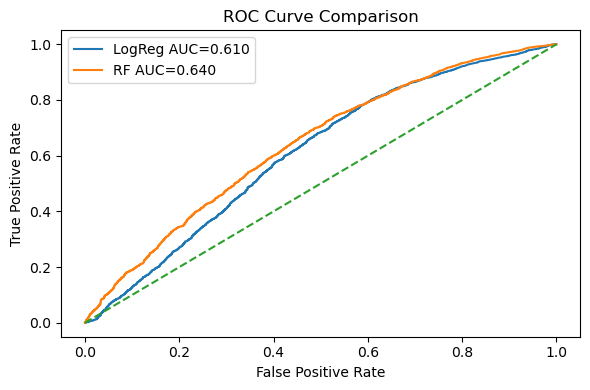

In [10]:
fpr, tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"LogReg AUC={log_auc:.3f}")
plt.plot(rf_fpr, rf_tpr, label=f"RF AUC={rf_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=300)
plt.show()

The ROC curve shows the trade-off between true positive rate and false positive rate for both models.

The Random Forest curve consistently stays above the Logistic Regression curve, indicating better discrimination ability across different thresholds.

The AUC values (0.64 for Random Forest and 0.61 for Logistic Regression) confirm that Random Forest provides stronger predictive performance under group-based validation.

Although neither model achieves extremely high accuracy, the curves demonstrate that both perform meaningfully better than random guessing.

------

## Feature importance (Random Forest)

This tells me what features matter most.

n_events               0.228417
session_time           0.182870
n_long_pauses          0.170170
early_std_dt           0.111550
mean_dt                0.106922
pause_ratio            0.084729
early_pause_ratio      0.063131
early_unique_events    0.052211
dtype: float64


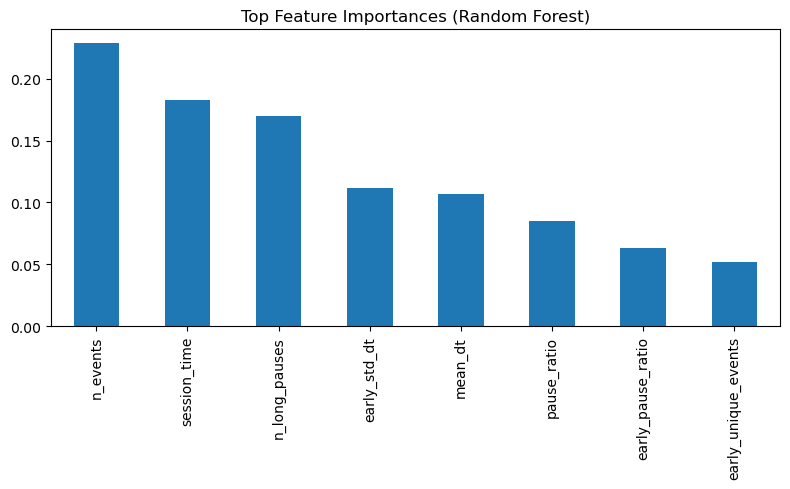

In [11]:
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(fi)

plt.figure(figsize=(8,5))
fi.head(10).plot(kind="bar")
plt.title("Top Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=300)
plt.show()

The most important features were:
- Total number of events
- Session time
- Number of long pauses
- Early timing volatility (early_std_dt)

This suggests that both overall engagement and early behavioral stability are important indicators of struggle.

-----

## Risk score + risk buckets (Using Random Forest)

Risk score = probability of incorrect (class 0).
Then I split into 5 groups from Very Low to Very High.

rf_risk_bucket
Very Low     0.956982
Low          0.930902
Medium       0.884669
High         0.834089
Very High    0.692976
Name: correct, dtype: float64


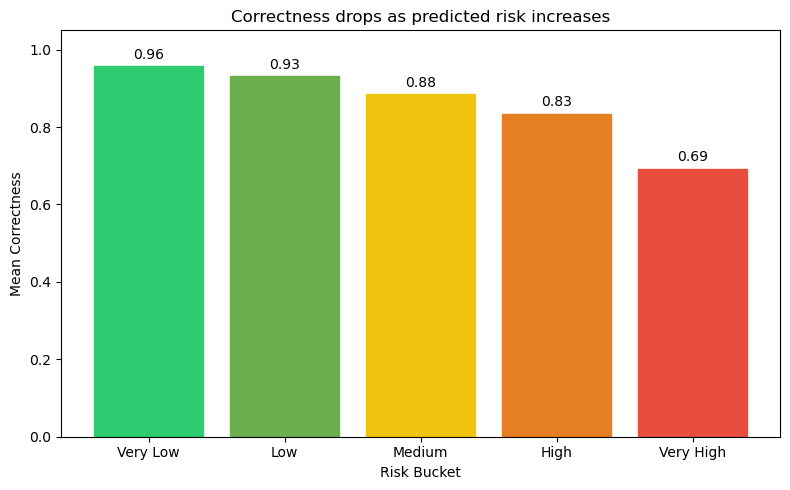

In [12]:
model_data["rf_risk_score"] = rf.predict_proba(X)[:, 0]  # P(incorrect)

model_data["rf_risk_bucket"] = pd.qcut(
    model_data["rf_risk_score"],
    q=5,
    labels=["Very Low","Low","Medium","High","Very High"]
)

rf_bucket_perf = model_data.groupby("rf_risk_bucket")["correct"].mean().sort_index()
print(rf_bucket_perf)

vals = rf_bucket_perf.values
labels_bucket = rf_bucket_perf.index.astype(str)

plt.figure(figsize=(8,5))
bars = plt.bar(labels_bucket, vals)

colors = ["#2ecc71", "#6ab04c", "#f1c40f", "#e67e22", "#e74c3c"]
for b, c in zip(bars, colors):
    b.set_color(c)

plt.ylim(0, 1.05)
plt.title("Correctness drops as predicted risk increases")
plt.xlabel("Risk Bucket")
plt.ylabel("Mean Correctness")

for i, v in enumerate(vals):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("rf_risk_bucket_bar.png", dpi=300)
plt.show()

The correctness rate steadily decreases as predicted risk increases.

- Very Low risk sessions have a correctness rate of about 96%.

- Very High risk sessions drop to about 69% correctness.

This clear downward trend shows that the model successfully ranks sessions by difficulty or struggle level. Even though the overall model performance is moderate, the risk score is effective for separating stronger sessions from more challenging ones.

The consistent pattern across buckets supports the practical use of the risk score for prioritizing intervention.

--------

## Intervention simulation (top 20% risk)

Question:
If we help only the highest-risk sessions (top 20%),
how many incorrect sessions are we covering?

In [13]:
threshold = model_data["rf_risk_score"].quantile(0.80)
high_risk = model_data[model_data["rf_risk_score"] >= threshold]

total_incorrect = (model_data["correct"] == 0).sum()
incorrect_in_high_risk = (high_risk["correct"] == 0).sum()
capture_rate = incorrect_in_high_risk / total_incorrect

print("Overall correctness rate:", model_data["correct"].mean())
print("High-risk correctness rate:", high_risk["correct"].mean())
print("Total incorrect sessions:", total_incorrect)
print("Incorrect in high-risk group:", incorrect_in_high_risk)
print("Capture rate of incorrect cases:", capture_rate)
print("High-risk group size:", high_risk.shape[0])

Overall correctness rate: 0.8599269337364576
High-risk correctness rate: 0.6930343872024184
Total incorrect sessions: 11119
Incorrect in high-risk group: 4874
Capture rate of incorrect cases: 0.4383487723716162
High-risk group size: 15878


The overall correctness rate in the dataset is about 86%, meaning most sessions are correct.

However, within the top 20% highest-risk sessions, the correctness rate drops to about 69%, indicating that this group contains many more struggling cases.

Out of 11,119 total incorrect sessions, the high-risk group contains 4,874 incorrect cases, which means the model captures about 44% of all incorrect outcomes while only flagging 20% of sessions.

This demonstrates that the risk score meaningfully concentrates struggling sessions into a smaller subset, making targeted intervention more efficient than random selection.

------

## Error analysis (confusion matrix)

This shows false positives / false negatives at threshold 0.5.

In [14]:
rf_preds = (rf_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, rf_preds)
print(cm)

[[  940  1224]
 [ 3203 10423]]


At a default 0.5 threshold, the model correctly identifies many correct sessions but misses a substantial number of incorrect cases, reinforcing the need for threshold optimization.

## Per-level-group modeling

I train a separate Random Forest model for each level_group:
- 0-4
- 5-12
- 13-22

This checks if prediction works better in certain stages of the game. For the per-level-group models, I used a standard train-test split for exploratory comparison. A group-based split was applied in the main model to prevent leakage across questions from the same gameplay session.

In [15]:
level_results = []

for level in sorted(model_data["level_group"].dropna().unique()):
    subset = model_data[model_data["level_group"] == level].copy()
    X_level = subset[feature_cols]
    y_level = subset["correct"]


    if y_level.nunique() < 2 or len(subset) < 200:
        continue

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_level, y_level, test_size=0.2, random_state=42, stratify=y_level
    )

    rf_level = RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf_level.fit(X_tr, y_tr)
    probs_level = rf_level.predict_proba(X_te)[:, 1]
    auc_level = roc_auc_score(y_te, probs_level)

    level_results.append((level, auc_level, len(subset)))

level_df = pd.DataFrame(level_results, columns=["Level Group","RF AUC","N rows"])
level_df

,Level Group,RF AUC,N rows
0,0-4,0.598149,70245
1,13-22,0.527919,1045
2,5-12,0.628888,8090


The model performs best in the 5–12 level group and weakest in 13–22, likely due to smaller sample size in later levels.

---

## Threshold optimization

Instead of always using top 20%,
I also check how recall changes at different thresholds.

Goal:
- pick a threshold that catches more incorrect sessions (higher recall)

Chosen threshold: 0.46186440677966095
Recall (incorrect): 0.5549907578558225
Intervention size: 0.37758074730842306


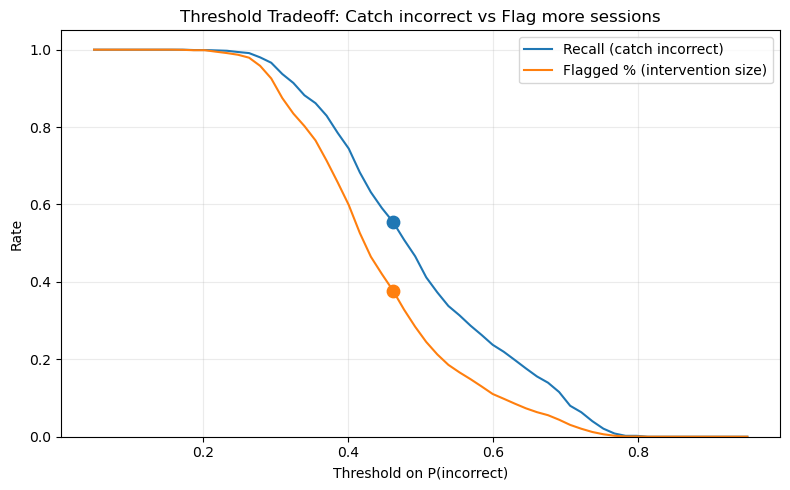

In [16]:
rf_probs_incorrect = rf.predict_proba(X_test)[:, 0]  # P(incorrect)
y_incorrect = (y_test == 0).astype(int)

ts = np.linspace(0.05, 0.95, 60)

rows = []
total_incorrect = y_incorrect.sum()

for t in ts:
    flagged = (rf_probs_incorrect >= t)
    recall_incorrect = ((flagged) & (y_incorrect == 1)).sum() / total_incorrect
    flagged_pct = flagged.mean()
    rows.append((t, recall_incorrect, flagged_pct))

threshold_df = pd.DataFrame(rows, columns=["threshold", "recall_incorrect", "flagged_pct"])

reasonable = threshold_df[threshold_df["flagged_pct"] <= 0.40].copy()
best_row = reasonable.sort_values("recall_incorrect", ascending=False).iloc[0]

print("Chosen threshold:", best_row["threshold"])
print("Recall (incorrect):", best_row["recall_incorrect"])
print("Intervention size:", best_row["flagged_pct"])

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["recall_incorrect"], label="Recall (catch incorrect)")
plt.plot(threshold_df["threshold"], threshold_df["flagged_pct"], label="Flagged % (intervention size)")
plt.scatter([best_row["threshold"]], [best_row["recall_incorrect"]], s=80)
plt.scatter([best_row["threshold"]], [best_row["flagged_pct"]], s=80)
plt.title("Threshold Tradeoff: Catch incorrect vs Flag more sessions")
plt.xlabel("Threshold on P(incorrect)")
plt.ylabel("Rate")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("threshold_tradeoff.png", dpi=300)
plt.show()

## Interpreting the Threshold Choice

I selected a threshold that keeps the intervention size below 40% while maximizing recall of incorrect sessions.

At this cutoff:

- The model captures about 55% of incorrect outcomes.

- About 38% of sessions would be flagged for support.

This shows that the system can focus on a smaller portion of sessions while still identifying a large number of struggling cases.

---

## Final model comparison table

This is a quick summary I can put in my report.

In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC AUC": [log_auc, rf_auc]
})
results

,Model,ROC AUC
0,Logistic Regression,0.609847
1,Random Forest,0.640216


## Model Comparison

The Random Forest model achieved a ROC AUC of approximately 0.64, while Logistic Regression achieved about 0.61.

This shows that the Random Forest model performs slightly better, likely because it can capture nonlinear patterns in gameplay behavior.

Although the overall performance is moderate, the improvement suggests that behavioral engagement features contain useful predictive information.

## Limitations

- Only 20% of gameplay logs were sampled due to computational constraints.
- The dataset is imbalanced (~14% incorrect sessions).
- Group-based splitting reduced performance compared to naive splitting, indicating prior leakage effects.
- Later level groups have substantially fewer observations.
- Overall model performance (AUC ≈ 0.64) reflects moderate predictive power and should not be considered production-ready.
- The system remains a research prototype and is not deployed in real time.

## Conclusion

In this project, I built a risk scoring model using early gameplay behavior to estimate which sessions are more likely to result in incorrect outcomes. I engineered both full session and early session features to capture patterns such as pauses, timing behavior, and engagement level.

After preventing data leakage using group-based splitting, the Random Forest model achieved a ROC AUC of about 0.64. While this is not extremely high, it shows that early gameplay behavior contains meaningful signals related to performance.

More importantly, the risk score was useful for ranking sessions. By focusing only on the highest-risk sessions, it was possible to capture a large portion of incorrect outcomes while intervening in a smaller percentage of total sessions. This shows practical value even with moderate predictive accuracy.

Overall, this project demonstrates that early behavioral data can be used to support targeted intervention strategies. With further feature engineering, larger data usage, and model tuning, the system could potentially improve and become more effective in real educational settings.